In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '..')
import codes.toolbox as tb

import warnings
warnings.filterwarnings("ignore")

from importlib import reload
reload(tb)

<module 'codes.toolbox' from '/Users/cfan/Documents/projects/202604_dailyStrategy/notebooks/../codes/toolbox.py'>

In [2]:
dl = tb.DataLoader('../data')
dl

DataLoader(symbols=0GUSDT .. ZRXUSDT (535 symbols), exchanges=(binance, bitget, bybit, okex), instruments=(futures, perps, spot, swap), dates=20250701 .. 20260412 (286 days))

In [3]:
dl.columns

['ts',
 'close',
 'volume_usdt',
 'cvd_usdt',
 'open_interest',
 'funding_rate',
 'funding_interval_hours']

In [4]:
def sigmoid(arr):
    return 1.0/(1.0 + np.exp(-1.0*arr))

def transformY(y, smooth = 0.0):
    if smooth < 1e-8:
        return (np.sign(y)+1.0)/2.0
    return sigmoid(y/smooth)

## Fit 4 hours, every 1 hour, horizon 24 hours

In [11]:
train_symbols = dl.symbols[::2]
valid_symbols = dl.symbols[1::2]

#features = ['dprice_ratio', 'dvolume_usdt_ratio', 'dcvd_usdt', 'doi', 'cvd_usdt']
features = ['log_oi_level', 'funding_rate', 'funding_7d_avg', 'ret_1h_pct',
       'ret_4h_pct', 'ret_1d_pct', 'ret_3d_pct', 'vol_1h_pct', 'vol_24h_pct',
       'vol_chg_4h_pct', 'oi_chg_4h_pct', 'oi_3d_chg_pct', 'oi_7d_chg_pct',
       'oi_coin_1h_chg_pct', 'oi_coin_chg_4h_pct', 'oi_coin_24h_chg_pct',
       'oi_coin_3d_chg_pct', 'oi_coin_7d_chg_pct', 'perp_cvd_1h', 'cvd_chg_4h',
       'perp_cvd_24h', 'perp_cvd_7d', 'spot_cvd_1h', 'spot_cvd_4h',
       'spot_cvd_24h', 'spot_cvd_7d', 'multi_exchange_spot_cvd_7d',
       'total_cvd_7d', 'multi_exchange_oi_7d_chg', 'spot_perp_vol_ratio',
       'spot_price_vs_perp']

horizons = [1,2,4,8,12, 16, 24, 32, 40, 48, 72]

markets = 'binance'
instruments = 'futures'

barFreq = 4

#df_train = tb.agg_justin_data(dl, train_symbols, markets, instruments, barFreq=barFreq, sampleFreq=1)
returns = tb.makeReturns(dl, df_train, horizons = horizons, adjustFundingRate=True,
                         addPumpLabel=True,
                          pumpThreshold=1.5,      
                          pumpForwardHours=14*24,
                          pumpMinHistoryHours=3*24)

X, Y, O = tb.makeXY(df_train, returns, features, appender=['volume_usdt'])

#df_valid =  tb.agg_justin_data(dl, valid_symbols, markets, instruments, barFreq=barFreq, sampleFreq=1)
returns = tb.makeReturns(dl, df_valid, horizons = horizons, adjustFundingRate=True,
                        addPumpLabel=True,
                          pumpThreshold=1.5,      
                          pumpForwardHours=14*24,
                          pumpMinHistoryHours=3*24)
X_valid, Y_valid, O_valid = tb.makeXY(df_valid, returns, features, appender=['volume_usdt'])

print ('trainX.shape', X.shape)
print ('validX.shape', X_valid.shape) 

Returns:   0%|          | 0/259 [00:00<?, ?it/s]

Returns:   0%|          | 0/258 [00:00<?, ?it/s]

trainX.shape (1405129, 31)
validX.shape (1312994, 31)


In [13]:
Dataset = {'X_train': X, 'Y_train': Y, 'O_train': O, 'X_valid': X_valid, 'Y_valid': Y_valid, 'O_valid': O_valid}
tb.savePickle(Dataset, './stockSplitData_justin.pkl')

In [5]:
Dataset = tb.loadPickle('./stockSplitData_justin.pkl')
X = Dataset['X_train']
Y = Dataset['Y_train']
O = Dataset['O_train'] 
X_valid = Dataset['X_valid'] 
Y_valid = Dataset['Y_valid']
O_valid = Dataset['O_valid']

In [6]:
select_features = [c for c in X.columns if '7d' not in c]

In [7]:
normalizer = tb.FeatureStater(group_mode = 'all') 
normalizer.fit(X, O)
X_norm = normalizer.transform(X,O, clip=False)
X_valid_norm = normalizer.transform(X_valid, O_valid, clip = False)

In [8]:
params = {
    "objective": "binary",
    "metric": ["binary_logloss", "auc"],
    "boosting_type": "gbdt",          # gbdt, dart, or goss
    "scale_pos_weight": 50.0,

    "num_leaves": 63,                  # max leaves per tree (main control of complexity)
    "max_depth": 5,                    # -1 = no limit; sometimes useful to cap
    "min_child_samples": 20,           # min data points in a leaf

    "learning_rate": 0.03,
    "n_estimators": 300,              # or use num_boost_round in lgb.train()

    "subsample": 0.8,                  # row sampling per tree
    "subsample_freq": 1,               # apply subsample every N iterations (1 = every tree)
    "colsample_bytree": 0.7,           # feature sampling per tree
    "colsample_bynode": 1.0,           # feature sampling per split
    
    "num_threads": -1,                 # -1 = use all cores

    "early_stopping_rounds": 50,       # stop if no improvement for N rounds
    "verbose" : 0,
}

In [9]:
params['scale_pos_weight'] = (Y.shape[0] - np.sum(Y['pump_label'].values))/np.sum(Y['pump_label'].values)
model_binary, loss_path = tb.fitLgb(X[select_features], Y['pump_label'].values,  params, log_period=50)

[50]	train's binary_logloss: 0.316811	train's auc: 0.885000	val's binary_logloss: 0.316811	val's auc: 0.885000
[100]	train's binary_logloss: 0.390241	train's auc: 0.896012	val's binary_logloss: 0.390241	val's auc: 0.896012
[150]	train's binary_logloss: 0.399075	train's auc: 0.905070	val's binary_logloss: 0.399075	val's auc: 0.905070
[200]	train's binary_logloss: 0.389549	train's auc: 0.913968	val's binary_logloss: 0.389549	val's auc: 0.913968
[250]	train's binary_logloss: 0.377522	train's auc: 0.922158	val's binary_logloss: 0.377522	val's auc: 0.922158
[300]	train's binary_logloss: 0.363640	train's auc: 0.930418	val's binary_logloss: 0.363640	val's auc: 0.930418


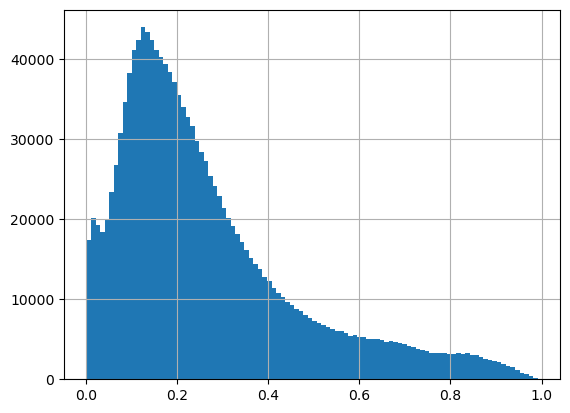

In [10]:
plt.figure()
plt.hist(model_binary.predict(X[select_features]), bins = 100)
plt.grid(True)

In [11]:
def binToDirectionY(ypred, central = 0.5):
    return (ypred-central)*2.0

def plotHistogram(model, X, X_valid, centralize=True):
    ypred_train = model.predict(X)
    ypred_valid = model.predict(X_valid)
    if centralize:
        central = np.median(ypred_train)
        ypred_train = binToDirectionY(ypred_train, central)
        ypred_valid = binToDirectionY(ypred_valid, central)

    plt.figure(figsize=(12,4))
    plt.subplot(1, 2, 1)
    plt.hist(ypred_train, bins = 100)
    plt.grid(True)
    plt.title('ytrain pred centered')

    plt.subplot(1,2,2)
    plt.hist(ypred_valid, bins = 100)
    plt.grid(True)
    plt.title('yvalid pred centered')

    plt.tight_layout()
    if centralize:
        return central
    return 0
    
def evalModelTrain(model, X_norm, Y, O, cutoff_quantiles, eval_horizon = 'ret_24h', statCol = 2, ypred_trans=None):
    ypred = model.predict(X_norm)
    if ypred_trans is not None:
        ypred = ypred_trans(ypred)

    cutoffs = np.quantile(abs(ypred), cutoff_quantiles)
    cutoff_names = [f"> {int(q*100)}%" for q in cutoff_quantiles]

    tb.MainEvaluateHorizons(ypred, Y, O, cutoffs, eval_horizon = eval_horizon, statCol = statCol, cutoff_names = cutoff_names)


def evalModelValid(model, X_train, X_valid, Y_valid, O_valid, cutoff_quantiles, eval_horizon = 'ret_24h', statCol = 2, ypred_trans=None):
    ytrain_pred = model.predict(X_norm)
    yvalid_pred = model.predict(X_valid)
    if ypred_trans is not None:
        yvalid_pred = ypred_trans(yvalid_pred)
        ytrain_pred = ypred_trans(ytrain_pred)

    cutoffs = np.quantile(abs(ytrain_pred), cutoff_quantiles)
    cutoff_names = [f"> {int(q*100)}%" for q in cutoff_quantiles]

    tb.MainEvaluateHorizons(yvalid_pred, Y_valid, O_valid, cutoffs, eval_horizon = eval_horizon, 
                            statCol = statCol, cutoff_names = cutoff_names)

In [12]:
ypred_train = model_binary.predict(X[select_features])
ypred_valid = model_binary.predict(X_valid[select_features])

In [13]:
def showPricePred(price_mat, pred_mat):
    plt.figure(figsize=(12,4))
    for i in range(price_mat.shape[0]):
        plt.subplot(1, 2, 1)
        plt.plot(price_mat[i,:], color = 'grey', alpha = 0.1)
        plt.subplot(1, 2, 2)
        plt.plot(pred_mat[i,:], color = 'grey', alpha = 0.1)
    max_idx = np.arange(len(price_mat[0,]))[price_mat[0] == 1.0]
    plt.subplot(1,2,1)
    plt.title('price')
    plt.plot(np.mean(price_mat, axis = 0), color = 'red')
    plt.axvline(max_idx, color = 'orange', linestyle = 'dashed')
    plt.grid(True)
    plt.subplot(1,2,2)
    plt.title('prediction')
    plt.axhline(0, color = 'black', linestyle = 'dashed')
    plt.axvline(max_idx, color = 'orange', linestyle = 'dashed')
    plt.plot(np.mean(pred_mat, axis = 0), color = 'red')
    plt.grid(True)

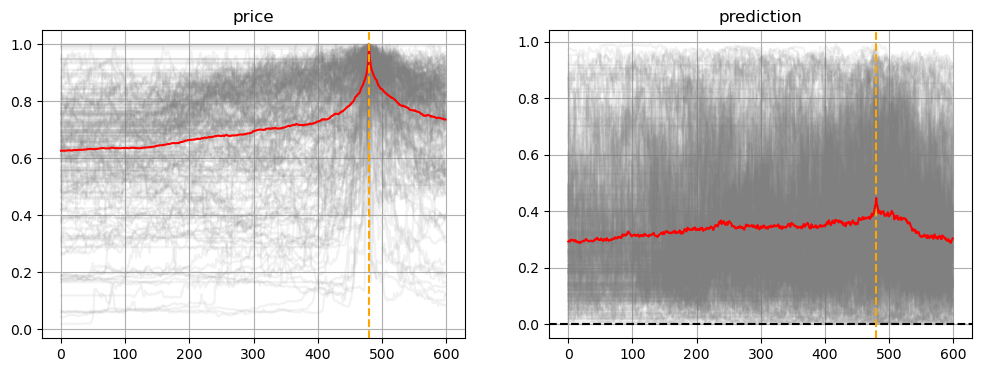

In [14]:
price_mat, pred_mat, *_ = tb.peakPredProfiles(ypred_train, O, left_days=20)
showPricePred(price_mat, pred_mat)

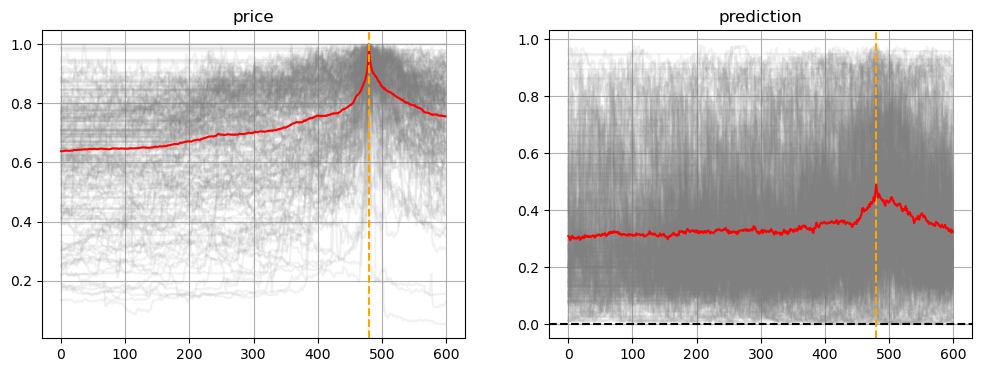

In [15]:
price_mat, pred_mat, *_ = tb.peakPredProfiles(ypred_valid, O_valid, left_days=20)
showPricePred(price_mat, pred_mat)

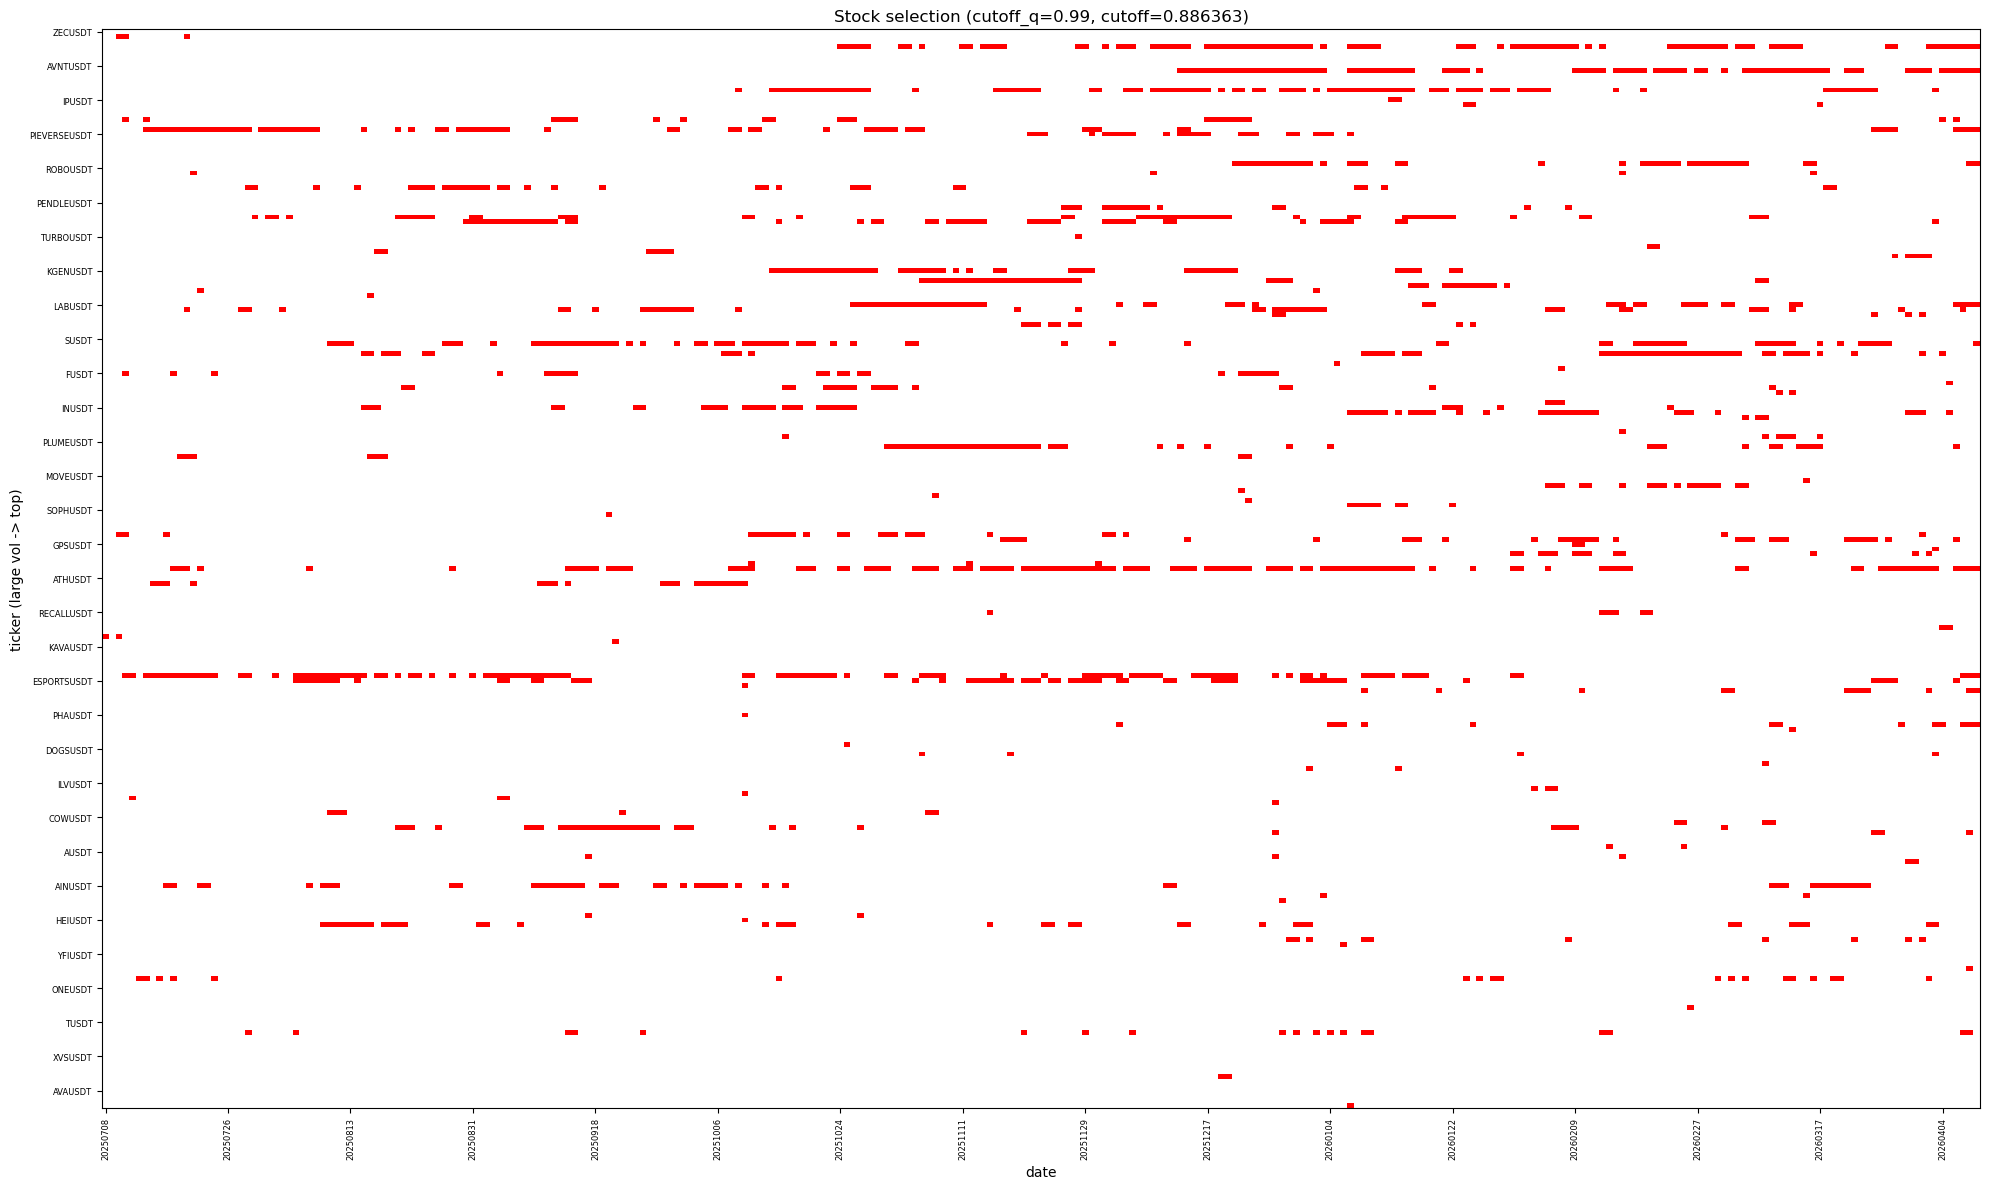

In [16]:
tb.showStockSelection(ypred_train, ypred_valid, O_valid, cutoff_quantile=0.990)

In [17]:
valid_long_short = tb.causal_long_short(np.where(ypred_valid > 0.9, 1.0, 0.0), O_valid)
train_long_short = tb.causal_long_short(np.where(ypred_train > 0.9, 1.0, 0.0), O)

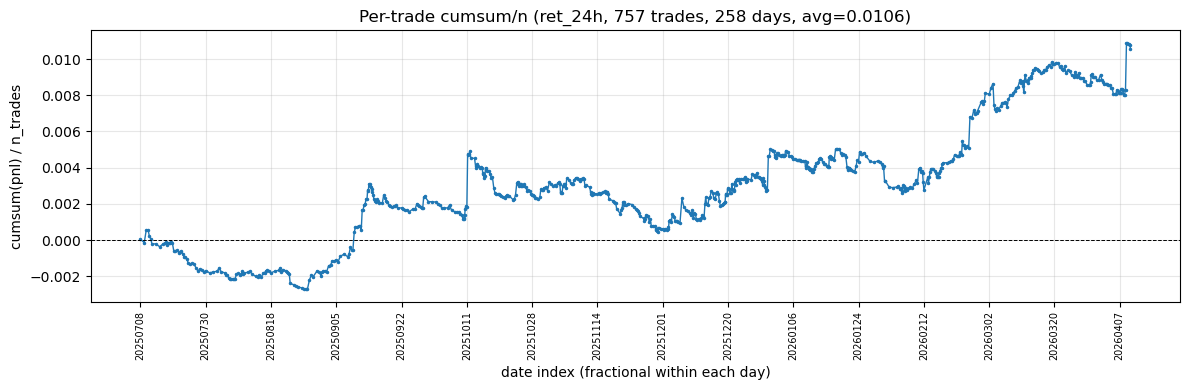

In [18]:
_ = tb.plotDailyReturnExactTrades(valid_long_short, Y_valid, O_valid, horizon='ret_24h')

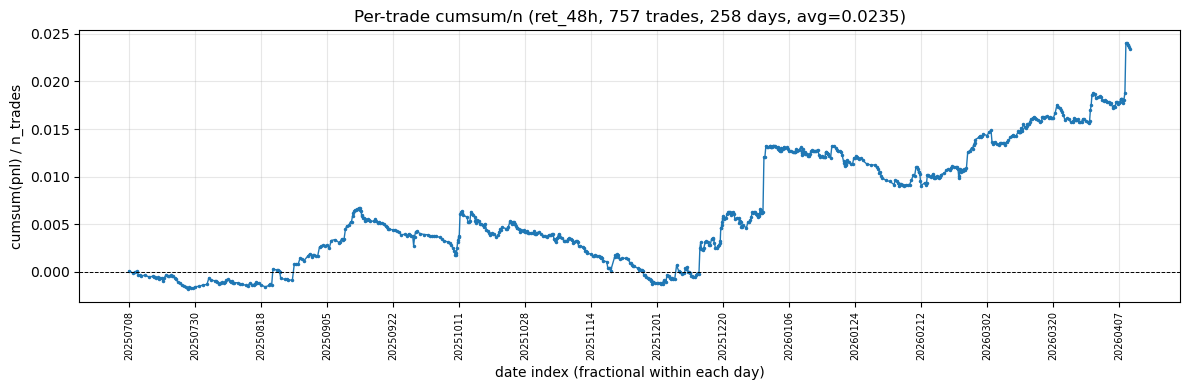

In [21]:
_ = tb.plotDailyReturnExactTrades(valid_long_short, Y_valid, O_valid, horizon='ret_48h')

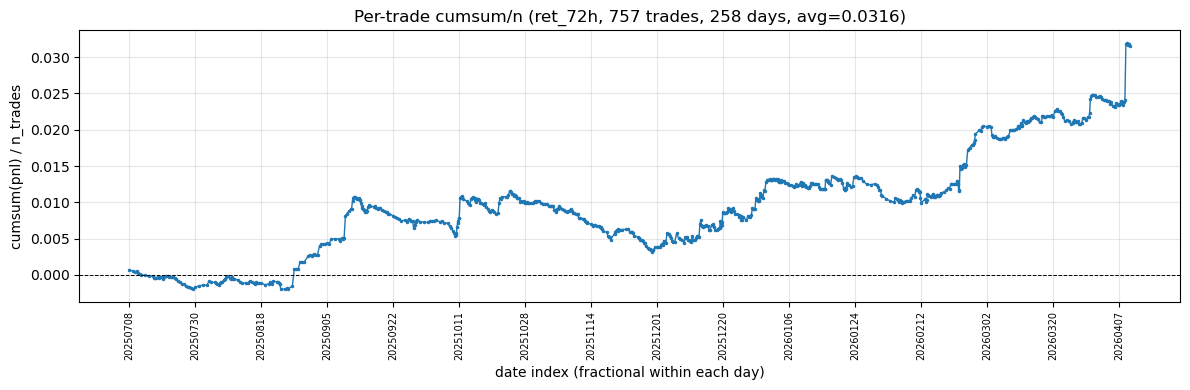

In [22]:
_ = tb.plotDailyReturnExactTrades(valid_long_short, Y_valid, O_valid, horizon='ret_72h')

In [19]:
rets = []
for h in Y_valid.columns[:-1]:
    daily_ret = tb.getDailyReturnExact(valid_long_short, Y_valid, O_valid, horizon=h)
    rets.append(np.mean(daily_ret.values))

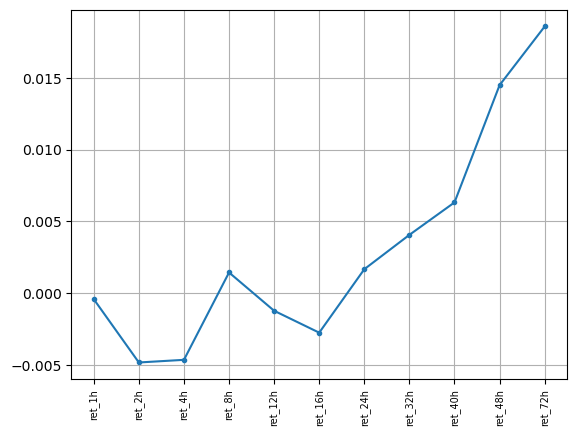

In [20]:
plt.figure()
plt.plot(np.arange(len(rets)), rets, '.-')
plt.xticks(np.arange(len(rets)), Y_valid.columns[:-1], rotation = 90, fontsize=7)
plt.grid(True)

In [113]:
info = tb.getLongShortInfo(valid_long_short, O_valid)

In [117]:
for t in matched:
    flag=False
    for matched_t in matched[t]:
        if matched_t in info.ticker.unique():
            print (f'ticker {t} found with {matched_t}')
            flag = True
    if not flag:
        print (f'ticker {t} with {matched[t]} NOT FOUND')

ticker RIVER found with RIVERUSDT
ticker AIA found with KAIAUSDT
ticker RAVE found with RAVEUSDT
ticker VVV found with VVVUSDT


### fit different horizons

In [69]:
params = {
    "objective": "binary",
    "metric": ["binary_logloss", "auc"],
    "boosting_type": "gbdt",          # gbdt, dart, or goss
    "scale_pos_weight": 50.0,

    "num_leaves": 63,                  # max leaves per tree (main control of complexity)
    "max_depth": 4,                    # -1 = no limit; sometimes useful to cap
    "min_child_samples": 100,           # min data points in a leaf

    "learning_rate": 0.01,
    "n_estimators": 600,              # or use num_boost_round in lgb.train()

    "subsample": 0.6,                  # row sampling per tree
    "subsample_freq": 1,               # apply subsample every N iterations (1 = every tree)
    "colsample_bytree": 0.6,           # feature sampling per tree
    "colsample_bynode": 1.0,           # feature sampling per split
    
    "num_threads": -1,                 # -1 = use all cores

    "early_stopping_rounds": 50,       # stop if no improvement for N rounds
    "verbose" : 0,
}

In [70]:
model_binary, loss_path = tb.fitLgb(X_norm, binaryLabel(Y['ret_48h'].values, 0.3),  params, log_period=100)

[100]	train's binary_logloss: 0.195125	train's auc: 0.845018	val's binary_logloss: 0.195125	val's auc: 0.845018
[200]	train's binary_logloss: 0.264077	train's auc: 0.852445	val's binary_logloss: 0.264077	val's auc: 0.852445
[300]	train's binary_logloss: 0.288841	train's auc: 0.861289	val's binary_logloss: 0.288841	val's auc: 0.861289
[400]	train's binary_logloss: 0.293997	train's auc: 0.870634	val's binary_logloss: 0.293997	val's auc: 0.870634
[500]	train's binary_logloss: 0.292362	train's auc: 0.879306	val's binary_logloss: 0.292362	val's auc: 0.879306
[600]	train's binary_logloss: 0.287803	train's auc: 0.888387	val's binary_logloss: 0.287803	val's auc: 0.888387


In [71]:
ypred_train = model_binary.predict(X_norm)
ypred_valid = model_binary.predict(X_valid_norm)
central     = np.median(ypred_train)
ypred_train = binToDirectionY(ypred_train, central)
ypred_valid = binToDirectionY(ypred_valid, central)

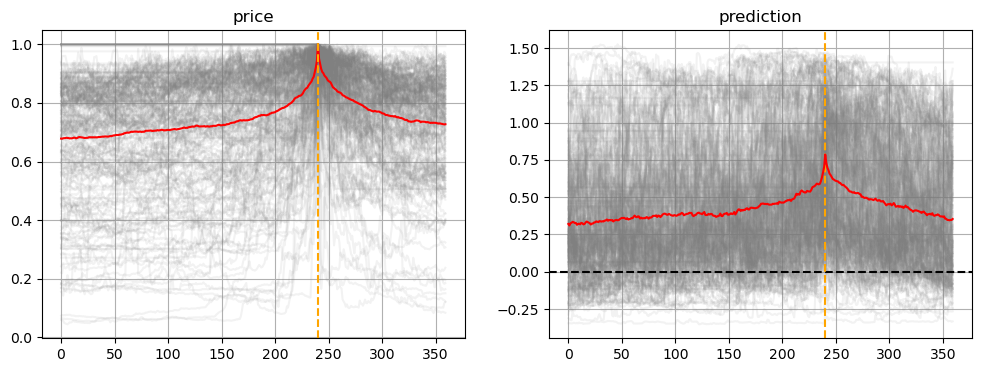

In [72]:
price_mat, pred_mat, *_ = tb.peakPredProfiles(ypred_train, O)
showPricePred(price_mat, pred_mat)

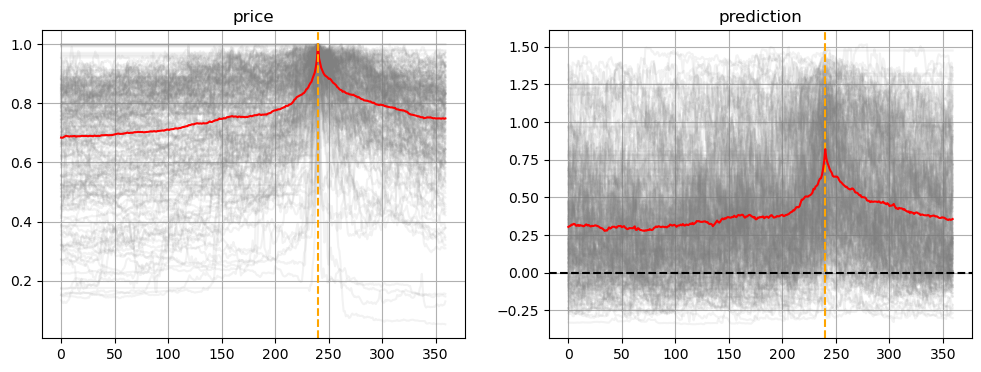

In [73]:
price_mat, pred_mat, *_ = tb.peakPredProfiles(ypred_valid, O_valid)
showPricePred(price_mat, pred_mat )

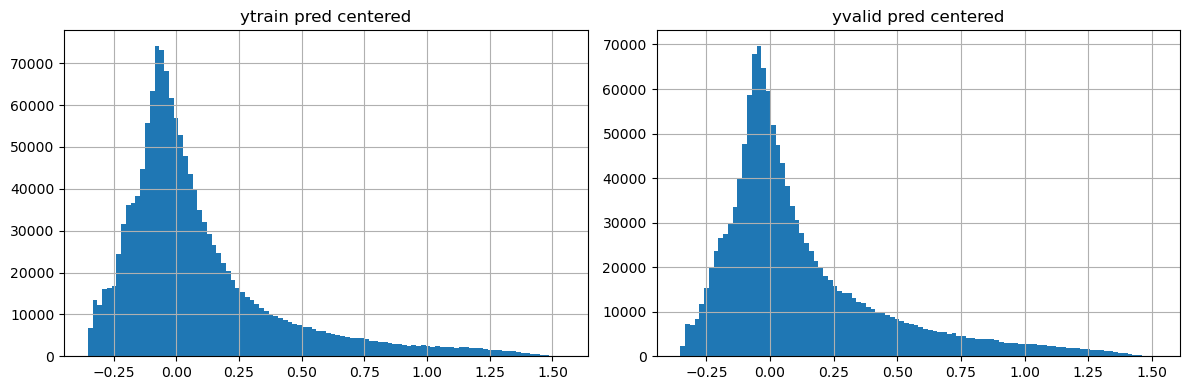

In [74]:
central = plotHistogram(model_binary, X_norm, X_valid_norm)

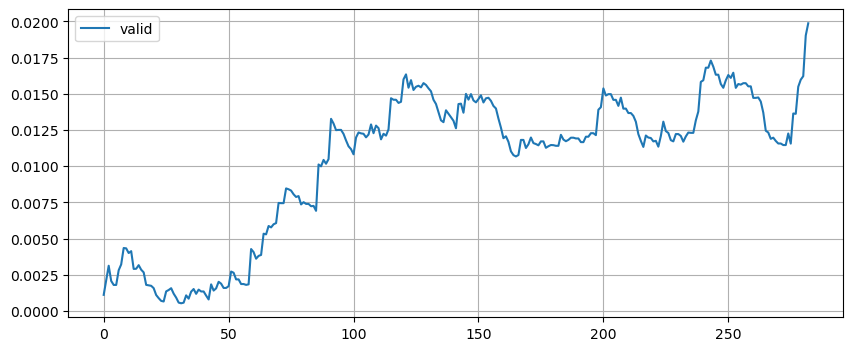

In [79]:
valid_long_short = tb.causal_long_short(np.where(ypred_valid > 1.25, 1.0, 0.0), O_valid)
train_long_short = tb.causal_long_short(np.where(ypred_train > 1.25, 1.0, 0.0), O)

daily_ret = tb.getDailyReturnExact(valid_long_short, Y_valid, O_valid, horizon='ret_32h')
daily_ret_train = tb.getDailyReturnExact(train_long_short, Y, O, horizon='ret_32h')
plt.figure(figsize=(10,4))
#plt.plot(np.cumsum(daily_ret_train.values)/len(daily_ret_train), label = 'train')
plt.plot(np.cumsum(daily_ret.values)/len(daily_ret), label = 'valid')
plt.grid(True)
plt.legend()

In [77]:
rets = []
for h in Y_valid.columns:
    daily_ret = tb.getDailyReturnExact(valid_long_short, Y_valid, O_valid, horizon=h)
    rets.append(np.mean(daily_ret.values))

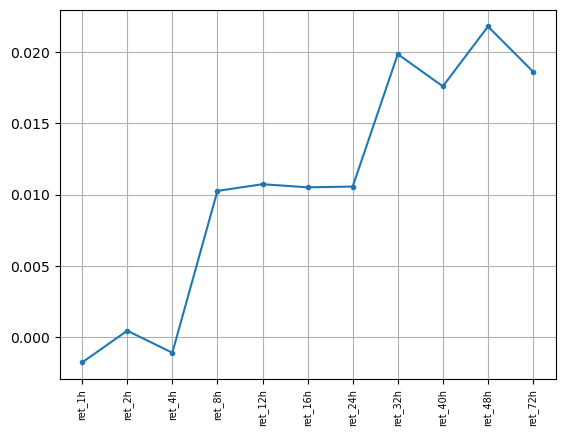

In [78]:
plt.figure()
plt.plot(np.arange(len(rets)), rets, '.-')
plt.xticks(np.arange(len(rets)), Y_valid.columns, rotation = 90, fontsize=7)
plt.grid(True)

In [80]:
valid_long_short = tb.causal_long_short(np.where(ypred_valid > 1.25, 1.0, 0.0), O_valid)

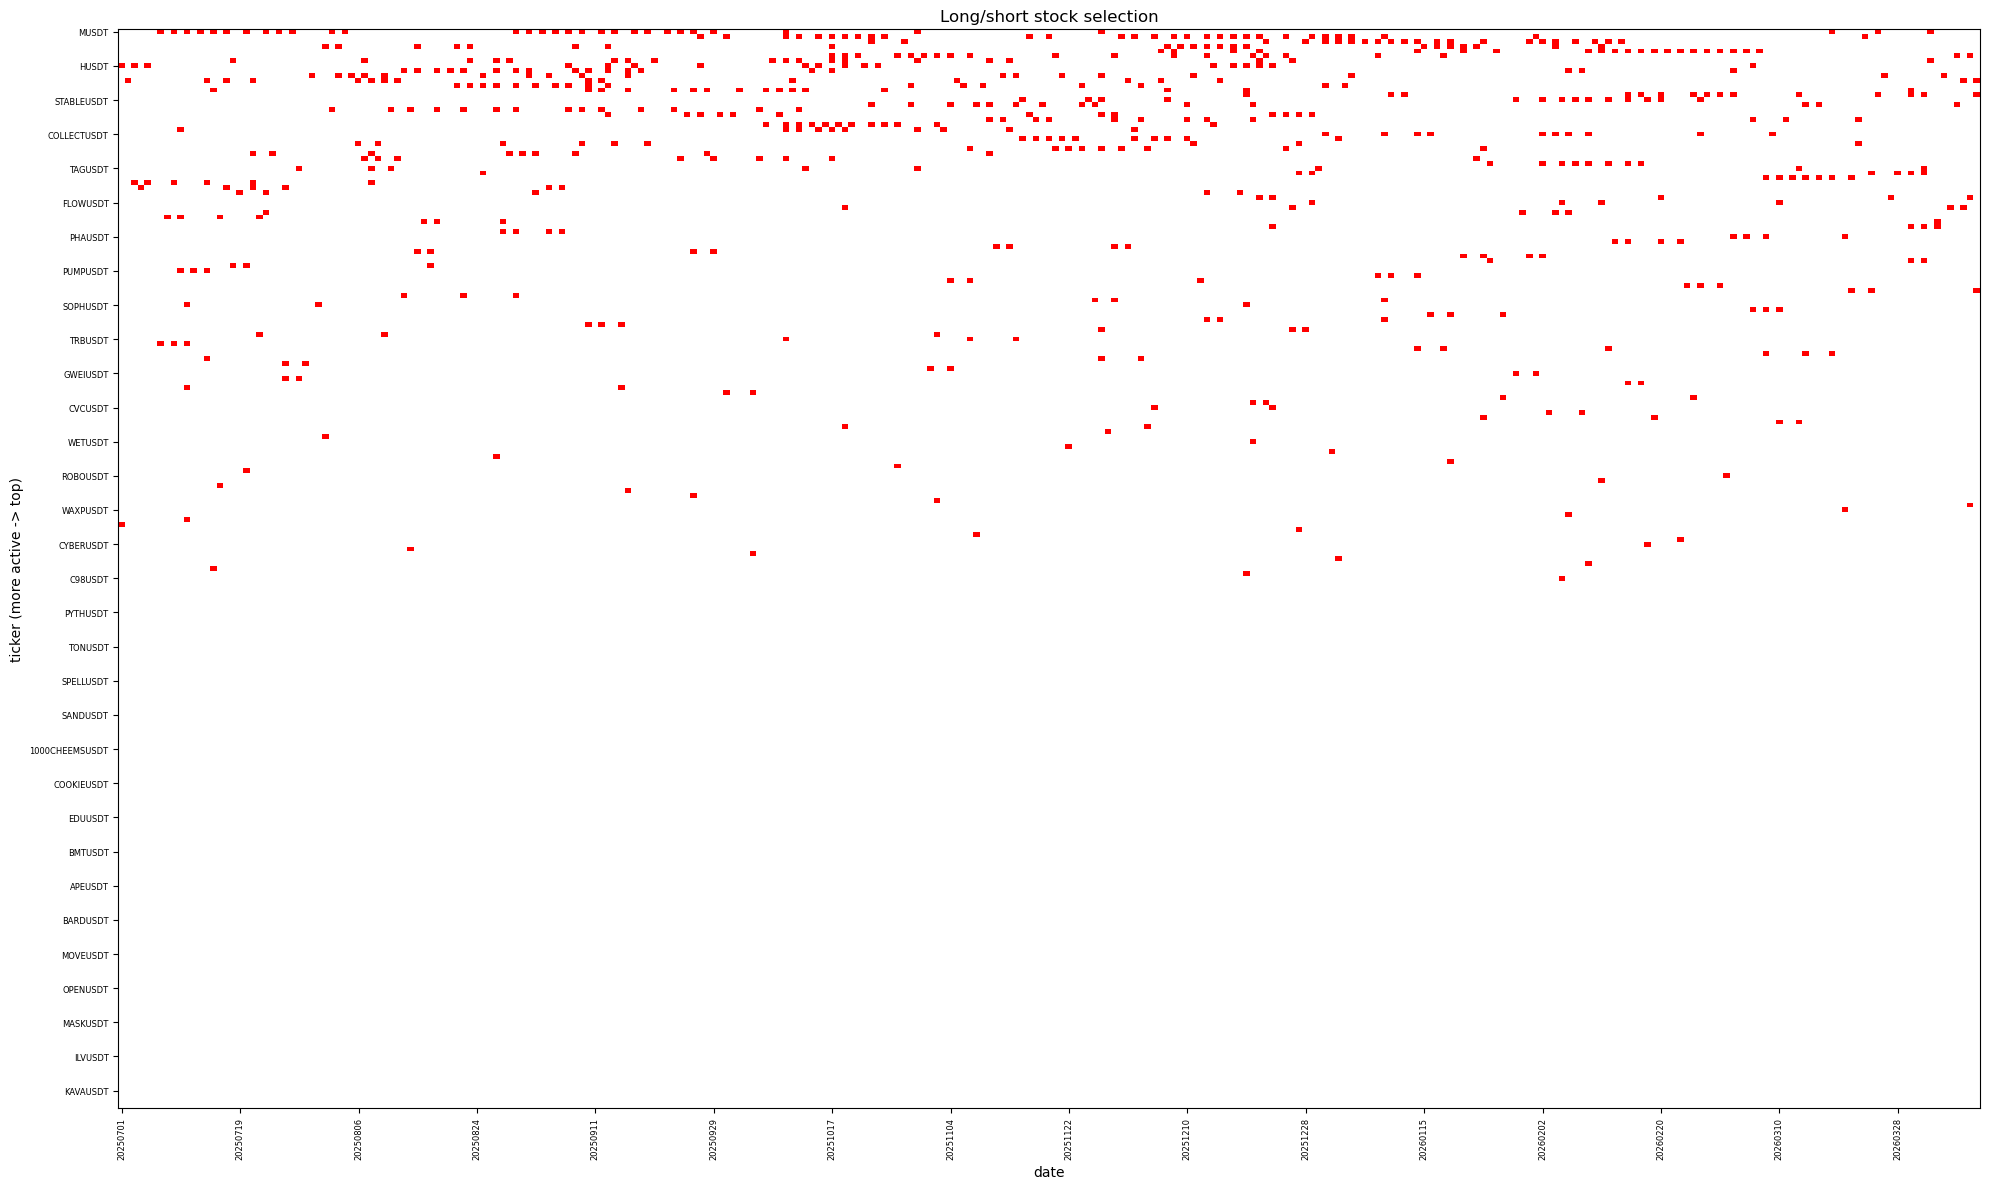

In [81]:
tb.showLongShortStockSelection(valid_long_short, O_valid)

In [82]:
similar_ticker= {}
binance_futures = set(dl.availSymbols('binance', 'futures'))
info = tb.getLongShortInfo(valid_long_short, O_valid)
for ticker in info.ticker.unique():
    for s in train_symbols:
        if s.find(ticker[:-4]) !=-1:
            if s not in binance_futures:
                continue
            if ticker not in similar_ticker:
                similar_ticker[ticker] = []
            similar_ticker[ticker].append(s)

In [83]:
leaked_symbol = list(similar_ticker.keys())
len(leaked_symbol)

16

In [84]:
len(leaked_symbol)

16

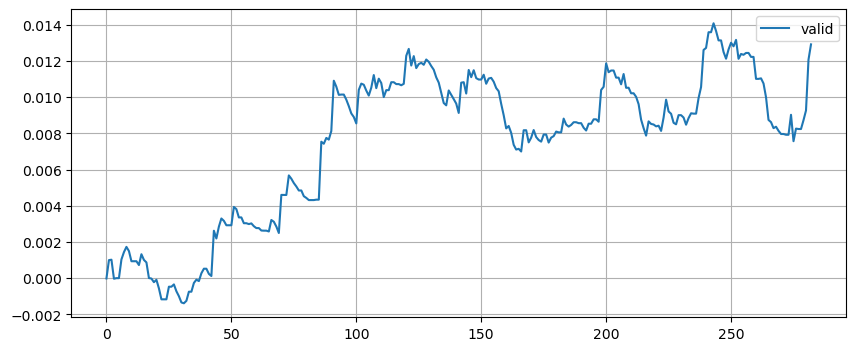

In [87]:
valid_long_short = tb.causal_long_short(np.where(ypred_valid > 1.25, 1.0, 0.0), O_valid)
train_long_short = tb.causal_long_short(np.where(ypred_train > 1.25, 1.0, 0.0), O)

daily_ret = tb.getDailyReturnExact(valid_long_short, Y_valid, O_valid, horizon='ret_32h', masked_tickers=leaked_symbol)
daily_ret_train = tb.getDailyReturnExact(train_long_short, Y, O, horizon='ret_32h')
plt.figure(figsize=(10,4))
#plt.plot(np.cumsum(daily_ret_train.values)/len(daily_ret_train), label = 'train')
plt.plot(np.cumsum(daily_ret.values)/len(daily_ret), label = 'valid')
plt.grid(True)
plt.legend()

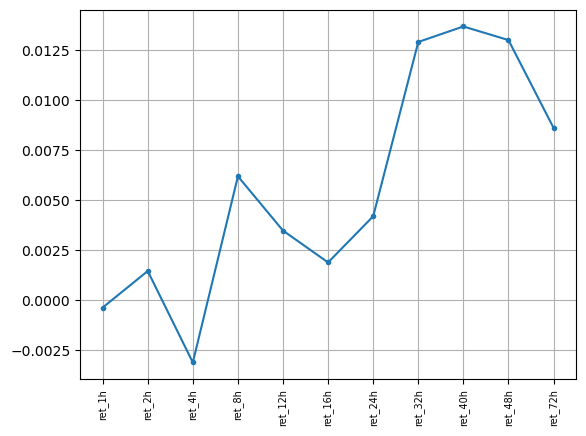

In [88]:
rets = []
for h in Y_valid.columns:
    daily_ret = tb.getDailyReturnExact(valid_long_short, Y_valid, O_valid, horizon=h, masked_tickers=leaked_symbol)
    rets.append(np.mean(daily_ret.values))
plt.figure()
plt.plot(np.arange(len(rets)), rets, '.-')
plt.xticks(np.arange(len(rets)), Y_valid.columns, rotation = 90, fontsize=7)
plt.grid(True)

In [89]:
strongSymbols = ['MYX', 'COAI', 'RIVER', 'AIA', 'SIREN', 'RAVE', 'BEAT', 'UAI', 'BULLA',  'ARIA', 'STI', 'HUMANITY' , 'VVV']

In [115]:
matched ={}
valid_symbols = O_valid.ticker.unique()
for s in strongSymbols:
    for t in valid_symbols:
        if t.find(s) !=-1:
            if s not in matched:
                matched[s] = []
            matched[s].append(t)

In [116]:
matched

{'RIVER': ['RIVERUSDT'],
 'AIA': ['KAIAUSDT'],
 'RAVE': ['RAVEUSDT'],
 'VVV': ['VVVUSDT']}

In [92]:
for t in matched:
    flag=False
    for matched_t in matched[t]:
        if matched_t in info.ticker.unique():
            print (f'ticker {t} found with {matched_t}')
            flag = True
    if not flag:
        print (f'ticker {t} with {matched[t]} NOT FOUND')

ticker RIVER found with RIVERUSDT
ticker AIA with ['KAIAUSDT'] NOT FOUND
ticker RAVE found with RAVEUSDT
ticker BEAT with ['BEATUSDT'] NOT FOUND
ticker UAI with ['BLUAIUSDT'] NOT FOUND
ticker BULLA with ['BULLAUSDT'] NOT FOUND
ticker VVV found with VVVUSDT


In [284]:
price_mat, pred_mat, peak_tickers, peak_times = tb.peakPredProfiles(ypred_valid, O_valid)

In [103]:
'VVVUSDT' in info.ticker.unique()

True

In [106]:
for t in matched:
    flag=False
    for matched_t in matched[t]:
        if matched_t in O_valid.ticker.unique():
            print (f'ticker {t} found with {matched_t}')
            flag = True
    if not flag:
        print (f'ticker {t} with {matched[t]} NOT FOUND')

ticker RIVER found with RIVERUSDT
ticker AIA found with KAIAUSDT
ticker RAVE found with RAVEUSDT
ticker BEAT with ['BEATUSDT'] NOT FOUND
ticker UAI with ['BLUAIUSDT'] NOT FOUND
ticker BULLA with ['BULLAUSDT'] NOT FOUND
ticker VVV found with VVVUSDT


In [107]:
'AIAUSDT' in O_valid.ticker.unique()

False